<a href="https://colab.research.google.com/github/Lobnaait/SEARCH_Lobna_Tsetline_CMRI/blob/main/Tsetline_ACDCdataset_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from huggingface_hub import snapshot_download
data_dir = snapshot_download(repo_id="mathpluscode/ACDC", allow_patterns=["*.nii.gz", "*.csv"], repo_type="dataset")
# https://huggingface.co/datasets/mathpluscode/ACDC

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 752 files:   0%|          | 0/752 [00:00<?, ?it/s]

In [2]:
!ls /root/.cache/huggingface/hub/datasets--mathpluscode--ACDC/snapshots/4a312b610f395eda5dc0aa36f087dd6ca9991e41/

test  test.csv	train  train.csv


In [3]:
!pip install pyTsetlinMachine

  Preparing metadata (setup.py) ... done
  Created wheel for pyTsetlinMachine: filename=pytsetlinmachine-0.6.6-cp313-cp313-linux_x86_64.whl size=59787 sha256=ceaccc07d61a1419d750a8b0811a12b33d6b2a25e9bbc4ae6975afd3be953eb9
  Stored in directory: /root/.cache/pip/wheels/a9/66/98/535c2cc844fdb6fc12f31feefbaa6a33222b1378914098f498
Successfully built pyTsetlinMachine


In [4]:
#IMPORT LIBRARIES
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, auc, roc_auc_score, classification_report, confusion_matrix
from pyTsetlinMachine.tm import MultiClassTsetlinMachine

In [5]:
#EXTRACT DATASET
import os

train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))

print(train.shape)
print(test.shape)

train.head(10)

(100, 15)
(50, 15)


,pid,pathology,height,weight,bmi,n_frames,ed_frame,es_frame,original_sax_spacing_x,original_sax_spacing_y,original_sax_spacing_z,n_slices,edv,esv,ef
0,patient001,DCM,1.84,95.0,28.060019,30,1,12,1.562500,1.562500,10.0,10,1354.58,1125.97,16.876818
1,patient002,DCM,1.60,70.0,27.343750,30,1,12,1.367188,1.367188,10.0,10,1212.69,979.53,19.226678
2,patient003,DCM,1.65,77.0,28.282828,30,1,15,1.562500,1.562500,10.0,10,1405.42,1298.96,7.574960
3,patient004,DCM,1.59,46.0,18.195483,28,1,15,1.367188,1.367188,10.0,10,1226.58,1114.83,9.110698
4,patient005,DCM,1.65,77.0,28.282828,30,1,13,1.406250,1.406250,10.0,10,1446.55,1211.36,16.258684
5,patient006,DCM,1.80,70.0,21.604938,28,1,16,1.757812,1.757812,10.0,11,1637.74,1374.18,16.092909
6,patient007,DCM,1.73,107.0,35.751278,16,1,7,1.875000,1.875000,10.0,10,1589.67,1411.75,11.192260
7,patient008,DCM,1.80,100.0,30.864198,28,1,13,1.562500,1.562500,10.0,10,1332.23,1158.90,13.010516
8,patient009,DCM,1.53,61.0,26.058354,35,1,13,1.367190,1.367190,10.0,10,1254.25,1154.37,7.963325
9,patient010,DCM,1.70,68.0,23.529412,28,1,13,1.562500,1.562500,10.0,10,1484.35,1316.59,11.301917


In [6]:
TARGET = "pathology"
print(train[TARGET].value_counts())


pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [7]:
# EXTRACT TRAININNG SET AND VALIDATION SET
print(train.columns.tolist())
features = train.columns.tolist()
features.remove(TARGET)
features.remove('pid')
print(features)

print("\n ")
X = train[features].copy()
y = train[TARGET].copy()

print("X_train shape:", X.shape)
print("y_train shape:", y.shape)
print("\nClasses:", y.value_counts())

['pid', 'pathology', 'height', 'weight', 'bmi', 'n_frames', 'ed_frame', 'es_frame', 'original_sax_spacing_x', 'original_sax_spacing_y', 'original_sax_spacing_z', 'n_slices', 'edv', 'esv', 'ef']
['height', 'weight', 'bmi', 'n_frames', 'ed_frame', 'es_frame', 'original_sax_spacing_x', 'original_sax_spacing_y', 'original_sax_spacing_z', 'n_slices', 'edv', 'esv', 'ef']

 
X_train shape: (100, 13)
y_train shape: (100,)

Classes: pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [8]:
# EXTRACT TEST SET
features = test.columns.tolist()
features.remove(TARGET)
features.remove('pid')

X_test = test[features].copy()
y_test = test[TARGET].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nClasses:", y_test.value_counts())


X_test shape: (50, 13)
y_test shape: (50,)

Classes: pathology
DCM     10
NOR     10
MINF    10
HCM     10
RV      10
Name: count, dtype: int64


In [9]:
def compute_thresholds_per_feature(X, n_thresholds_list):
    """n_thresholds_list: lista con un intero per ogni feature (colonna di X)"""
    thresholds = []
    for feature_index in range(X.shape[1]):
        n_thresholds = n_thresholds_list[feature_index]
        percentile_values = np.linspace(0, 100, int(n_thresholds) + 2)[1:-1]
        feature_thresholds = np.percentile(X[:, feature_index], percentile_values)
        feature_thresholds = np.unique(feature_thresholds)
        thresholds.append(feature_thresholds)
    return thresholds

In [10]:
# ---------------------------------------------------------
# Convert continuous features into binary features
# ---------------------------------------------------------
import numpy as np

def threshold_binarize(X, thresholds):
    binary_features = []

    for feature_index in range(X.shape[1]):
        for threshold in thresholds[feature_index]:
            binary_features.append( (X[:, feature_index] >= threshold).astype(np.uint32) )

    return np.array(binary_features).T

In [ ]:
def optimize_thresholds_per_feature(
    X_train, y_train, X_val, y_val,
    threshold_candidates=range(1, 11),
    n_rounds=2,
    default_n=5,
    search_epochs=30,          # epoche ridotte per velocizzare la ricerca
    number_of_clauses=1000, T=50, s=5.0
):
    n_features = X_train.shape[1]
    n_thresholds_per_feature = [default_n] * n_features

    for round_idx in range(n_rounds):
        print(f"\n=== Round {round_idx + 1} ===")
        for feat_idx in range(n_features):
            best_feat_score = -np.inf
            best_feat_n = n_thresholds_per_feature[feat_idx]

            for candidate in threshold_candidates:
                trial = n_thresholds_per_feature.copy()
                trial[feat_idx] = candidate

                thresholds = compute_thresholds_per_feature(X_train, trial)
                X_train_bin = threshold_binarize(X_train, thresholds)
                X_val_bin = threshold_binarize(X_val, thresholds)

                tm = MultiClassTsetlinMachine(number_of_clauses, T, s)
                tm.fit(X_train_bin, y_train, epochs=search_epochs)
                preds = tm.predict(X_val_bin)
                score = f1_score(y_val, preds, average="macro")

                if score > best_feat_score:
                    best_feat_score = score
                    best_feat_n = candidate

            n_thresholds_per_feature[feat_idx] = best_feat_n
            print(f"Feature {feat_idx:2d} ({features[feat_idx]}): "
                  f"soglie ottimali = {best_feat_n:2d} | macro F1 = {best_feat_score:.4f}")

    return n_thresholds_per_feature

In [11]:
# Reproducible split
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.25, stratify=y)

# Convert pandas dataframes to NumPy
X_train_np = X_train.to_numpy(dtype=np.float32)
X_validation_np = X_validation.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)

# Encode class labels as integers
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_validation_enc = label_encoder.transform(y_validation)
y_test_enc = label_encoder.transform(y_test)

In [12]:
best_n_thresholds_per_feature = optimize_thresholds_per_feature(
    X_train_np, y_train_enc, X_validation_np, y_validation_enc,
    threshold_candidates=range(1, 11),
    n_rounds=2
)

print("\nSoglie ottimali per feature:")
for f, n in zip(features, best_n_thresholds_per_feature):
    print(f"  {f}: {n}")

# Training finale su train+validation con le soglie per-feature trovate
X_train_full = np.vstack([X_train_np, X_validation_np])
y_train_full = np.concatenate([y_train_enc, y_validation_enc])

final_thresholds = compute_thresholds_per_feature(X_train_full, best_n_thresholds_per_feature)
X_train_full_bin = threshold_binarize(X_train_full, final_thresholds)
X_test_bin = threshold_binarize(X_test_np, final_thresholds)

print("\nFinal training shape:", X_train_full_bin.shape)
print("Final test shape:", X_test_bin.shape)

final_tm = MultiClassTsetlinMachine(1000, 50, 5.0)
final_tm.fit(X_train_full_bin, y_train_full, epochs=100)
test_predictions = final_tm.predict(X_test_bin)

Thresholds:  1 | accuracy: 0.3600 |Macro F1: 0.3483
Thresholds:  2 | accuracy: 0.4400 |Macro F1: 0.4378
Thresholds:  3 | accuracy: 0.4000 |Macro F1: 0.4054
Thresholds:  4 | accuracy: 0.4400 |Macro F1: 0.4302
Thresholds:  5 | accuracy: 0.5200 |Macro F1: 0.5202
Thresholds:  6 | accuracy: 0.4000 |Macro F1: 0.3894
Thresholds:  7 | accuracy: 0.4400 |Macro F1: 0.4198
Thresholds:  8 | accuracy: 0.4400 |Macro F1: 0.4378
Thresholds:  9 | accuracy: 0.4000 |Macro F1: 0.3979
Thresholds: 10 | accuracy: 0.4400 |Macro F1: 0.4232


In [13]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

print(results_df)

best_n_thresholds = int(
    results_df.loc[
        results_df["macro_f1"].idxmax(),
        "n_thresholds"
    ]
)

print(
    "Optimal number of thresholds:",
    best_n_thresholds
)


   n_thresholds  binary_features  accuracy  macro_f1
0             5               52      0.52  0.520202
1             2               24      0.44  0.437778
2             8               81      0.44  0.437778
3             4               45      0.44  0.430202
4            10               98      0.44  0.423232
5             7               71      0.44  0.419841
6             3               34      0.40  0.405397
7             9               89      0.40  0.397863
8             6               63      0.40  0.389394
9             1               13      0.36  0.348254
Optimal number of thresholds: 5


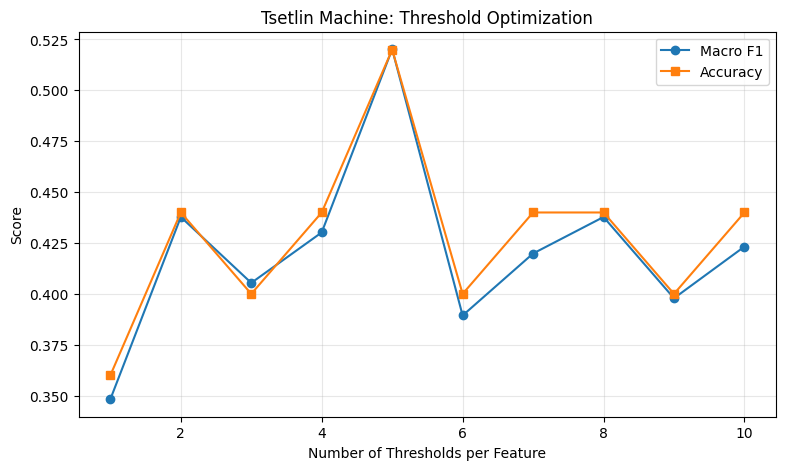

In [14]:
import matplotlib.pyplot as plt

results_sorted = results_df.sort_values("n_thresholds")

plt.figure(figsize=(9, 5))

plt.plot(
    results_sorted["n_thresholds"],
    results_sorted["macro_f1"],
    marker="o",
    label="Macro F1"
)

plt.plot(
    results_sorted["n_thresholds"],
    results_sorted["accuracy"],
    marker="s",
    label="Accuracy"
)

plt.xlabel("Number of Thresholds per Feature")
plt.ylabel("Score")
plt.title("Tsetlin Machine: Threshold Optimization")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [15]:
X_train_full = np.vstack([ X_train_np,X_validation_np])
y_train_full = np.concatenate([y_train_enc,y_validation_enc])

# Recalculate thresholds using ALL training data
final_thresholds = compute_thresholds( X_train_full, best_n_thresholds)
X_train_full_bin = threshold_binarize(X_train_full, final_thresholds)
X_test_bin = threshold_binarize(X_test_np, final_thresholds)

print("Final training shape:", X_train_full_bin.shape)
print("Final test shape:", X_test_bin.shape)

final_tm = MultiClassTsetlinMachine(1000,50,5.0)

final_tm.fit( X_train_full_bin, y_train_full, epochs=100)

test_predictions = final_tm.predict(X_test_bin)

Final training shape: (100, 52)
Final test shape: (50, 52)


In [16]:
print("Test Accuracy:",accuracy_score(y_test_enc, test_predictions))
print("Test Macro F1:", f1_score( y_test_enc, test_predictions, average="macro"))
print("\nClassification Report:")
print(classification_report(y_test_enc,test_predictions,target_names=label_encoder.classes_ ))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc,test_predictions))

Test Accuracy: 0.6
Test Macro F1: 0.6032826631796884

Classification Report:
              precision    recall  f1-score   support

         DCM       0.73      0.80      0.76        10
         HCM       0.46      0.60      0.52        10
        MINF       0.83      0.50      0.62        10
         NOR       0.45      0.50      0.48        10
          RV       0.67      0.60      0.63        10

    accuracy                           0.60        50
   macro avg       0.63      0.60      0.60        50
weighted avg       0.63      0.60      0.60        50


Confusion Matrix:
[[8 2 0 0 0]
 [0 6 1 3 0]
 [3 2 5 0 0]
 [0 2 0 5 3]
 [0 1 0 3 6]]
